# Apply noise maps to UVEX simulated data

This notebook demonstrates how detector-specific read-noise, dark-current, and
bias calibration maps are inspected and applied to simulated UVEX NUV detector
data in ScopeSim.

Each detector (A1–C3) is assigned 4096 × 4096 FITS calibration maps describing
the pixel-dependent detector properties:

- **Read noise:** per-pixel read-noise RMS, $\sigma_{\rm RN}$, in
  e⁻/pixel/read. A new Gaussian noise realization is drawn from this RMS map
  for each simulated readout.
- **Dark current:** per-pixel dark-current rate in e⁻/pixel/s. The rate map is
  scaled by the simulated exposure time to determine the accumulated dark
  signal.
- **Bias:** per-pixel electronic bias offset in e⁻/pixel. The bias map is added
  to the detector signal as a fixed spatial offset.

The detector-specific calibration files are defined in
`calibration_config.yaml` and are selected using the physical detector name
(A1–C3).

This notebook verifies that:

- the correct calibration maps are selected for each physical detector;
- the simulated read-noise distribution is consistent with the input RMS map;
- read noise scales appropriately with the number of detector reads (`NDIT`);
- dark current scales appropriately with exposure time;
- the detector-specific bias pattern is correctly added to the simulated data;
- the calibration effects are correctly applied in a full UVEX simulation.

The current calibration maps are provisional synthetic maps. They can be
replaced by measured detector calibration products without changing the
simulation workflow.

In [1]:
import scopesim as sim
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from astropy.io import fits
from scopesim.detector import Detector
from pathlib import Path
import sys


# Path to UVEX calibration code
code_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/code"
)

sys.path.insert(0, str(code_dir))


from detector_calibration import (create_blank_detector)


sim.link_irdb(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb"
)

simulation = sim.Simulation("UVEX", mode=["nuv"])

astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits
astar.scopesim.optics.fov_manager - WARNING: For use with the UVEX Slit Mask effect, it's recommended that oversampling_x is even.


In [2]:
# UVEX calibration configuration
uvex_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX"
)
config_path = uvex_dir / "calibration_config.yaml"

### Verifying correct read noise map loaded

In [3]:
rn = simulation.optical_train["readout_noise"]

print(type(rn))
print(rn.meta["calibration_config"])

<class 'scopesim.effects.electronic.noise.BasicReadoutNoiseMap'>
calibration_config.yaml


### Inspecting Read Noise Map properties (per detector, these are from the RMS calibration map)

In [4]:
# Choose a detector to inspect
detector_name = "B2"

# Read the calibration configuration
with open(config_path, "r") as f:
    calibration_config = yaml.safe_load(f)

# Find and load this detector's read-noise RMS map
read_noise_filename = (
    calibration_config["detectors"][detector_name]["read_noise"]
)
read_noise_path = uvex_dir / read_noise_filename

read_noise_map = fits.getdata(read_noise_path)

print(f"Detector: {detector_name}")
print(f"File: {read_noise_path}")
print(f"Shape: {read_noise_map.shape}")
print(f"Mean RMS: {np.mean(read_noise_map):.3f} e-/pixel/read")
print(f"Median RMS: {np.median(read_noise_map):.3f} e-/pixel/read")
print(f"Std. of pixel RMS values: {np.std(read_noise_map):.3f} e-")
print(f"Min: {np.min(read_noise_map):.3f} e-")
print(f"Max: {np.max(read_noise_map):.3f} e-")

Detector: B2
File: /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/B2/UVIM_DET_read_noise_RN2p0_var0p5.fits
Shape: (4096, 4096)
Mean RMS: 2.000 e-/pixel/read
Median RMS: 2.000 e-/pixel/read
Std. of pixel RMS values: 0.500 e-
Min: 0.000 e-
Max: 4.656 e-


### Applying Read Noise only to a blank image

#### Creating blank detector image

In [5]:
#making blank detector
blank_det = create_blank_detector(detector_name)

In [6]:
# Get the read-noise effect from the simulation
rn = simulation.optical_train["readout_noise"]

# Apply only the read-noise effect
rn.apply_to(blank_det)

# Extract the resulting image
noise_image = blank_det._hdu.data

print("Mean:", np.mean(noise_image))
print("Median:", np.median(noise_image))
print("Std:", np.std(noise_image))

Mean: -0.0005039600077100179
Median: -0.0004980783134644776
Std: 2.0625789012283424


#### Visualizing measured read noise values on blank detector (as selected from the RMS readnoise values in the above figure)

For the example provisional files, the read noise was set to have a median value of 2 or 5 e-/pix/read and the pixel variation was set to be 0.2 or 0.5 e-. 

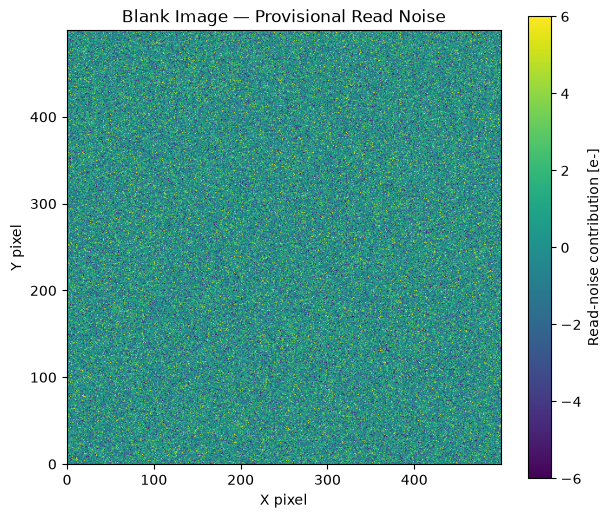

In [7]:
#select smaller area of full image to visualize noise pattern
patch = noise_image[1000:1500, 1000:1500]


#plot noise map
plt.figure(figsize=(7, 6))

plt.imshow(
    patch,
    origin="lower",
    vmin=-6,
    vmax=6
)

plt.colorbar(label="Read-noise contribution [e-]")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("Blank Image — Provisional Read Noise")

plt.show()

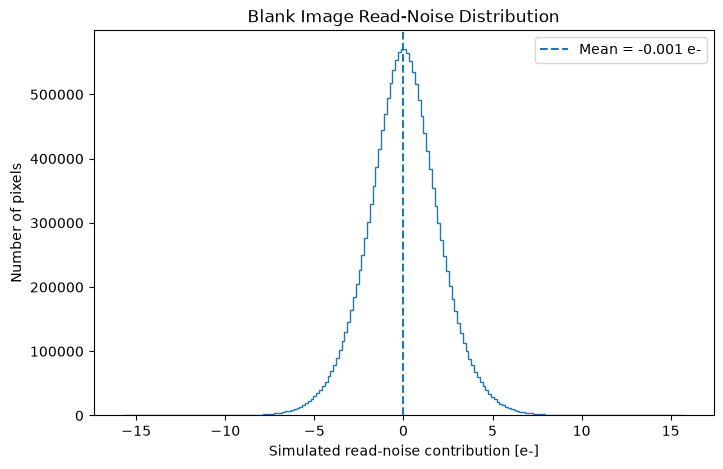

In [8]:
#plt histogram of all pixel values (only read noise)
plt.figure(figsize=(8, 5))

plt.hist(
    noise_image.ravel(),
    bins=200,
    histtype="step"
)

plt.axvline(
    np.mean(noise_image),
    linestyle="--",
    label=f"Mean = {np.mean(noise_image):.3f} e-"
)

plt.xlabel("Simulated read-noise contribution [e-]")
plt.ylabel("Number of pixels")
plt.title("Blank Image Read-Noise Distribution")
plt.legend()

plt.show()

#### Visualizing read noise values for all 9 UVEX detectors

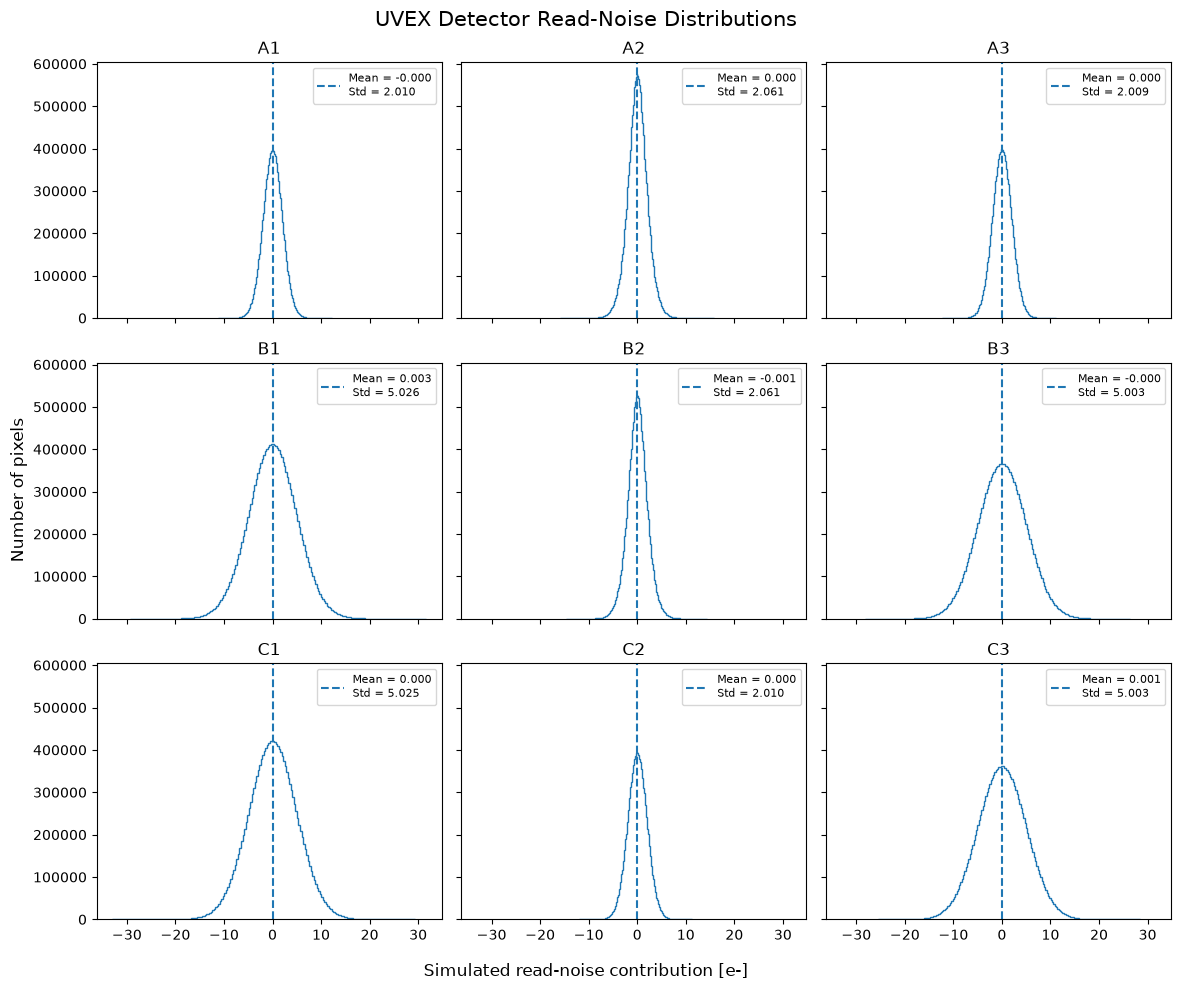

In [9]:
# Physical detector layout
detector_grid = [
    ["A1", "A2", "A3"],
    ["B1", "B2", "B3"],
    ["C1", "C2", "C3"],
]

# Get the read-noise effect
rn = simulation.optical_train["readout_noise"]

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)

for row, detector_row in enumerate(detector_grid):
    for col, detector_name in enumerate(detector_row):

        # Create a blank detector
        header = fits.Header()
        header["NAXIS"] = 2
        header["NAXIS1"] = 4096
        header["NAXIS2"] = 4096

        blank_det = Detector(header)

        # Tell the calibration system which detector this is
        blank_det._hdu.header["NAME"] = detector_name

        # Apply only the read-noise effect
        rn.apply_to(blank_det)
        noise_image = blank_det._hdu.data

        # Calculate statistics
        mean = np.mean(noise_image)
        std = np.std(noise_image)

        # Plot distribution
        ax = axes[row, col]

        ax.hist(
            noise_image.ravel(),
            bins=200,
            histtype="step",
        )

        ax.axvline(
            mean,
            linestyle="--",
            label=f"Mean = {mean:.3f}\nStd = {std:.3f}"
        )

        ax.set_title(detector_name)
        ax.legend(fontsize=8)

# Shared labels
fig.supxlabel("Simulated read-noise contribution [e-]")
fig.supylabel("Number of pixels")
fig.suptitle(
    "UVEX Detector Read-Noise Distributions",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Validating the dark current map

For the example provisional files, the dark current was set to have a mean value of 0.01 e-/s and the pixel variation was set to be 0.002 e-/s. The nominal exposure time for the simulation is 300 seconds, so we expect:

Expected mean:  3.0 e-

Expected std:   0.6 e- 

In [10]:
# Get the dark-current effect
dc = simulation.optical_train["dark_current"]

# Create a blank B2 detector
blank_det = create_blank_detector("B2")

# Apply dark current
dc.apply_to(blank_det)

dark_image = blank_det._hdu.data

print("Min:   ", np.min(dark_image))
print("Max:   ", np.max(dark_image))
print("Mean:  ", np.mean(dark_image))
print("Median:", np.median(dark_image))
print("Std:   ", np.std(dark_image))

print()

print("DIT: ", simulation.optical_train.cmds["!OBS.dit"])
print("NDIT:", simulation.optical_train.cmds["!OBS.ndit"])

Min:    0.0
Max:    6.18710470199585
Mean:   2.999910983535072
Median: 2.999836564064026
Std:    0.5998706366556065

DIT:  300
NDIT: 1


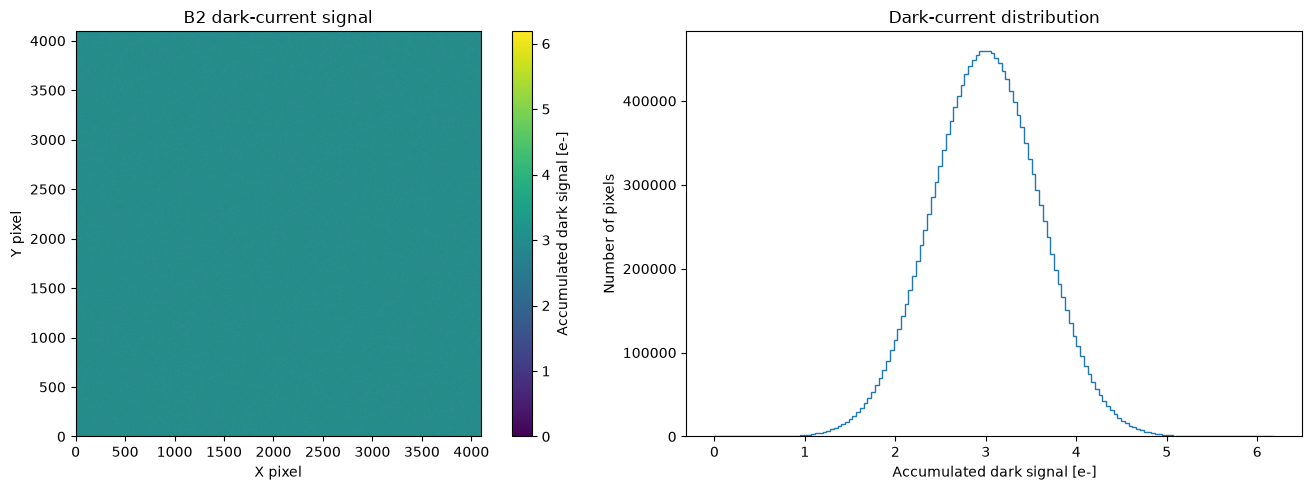

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(
    dark_image,
    origin="lower",
)
plt.colorbar(im, ax=axes[0], label="Accumulated dark signal [e-]")

axes[0].set_title("B2 dark-current signal")
axes[0].set_xlabel("X pixel")
axes[0].set_ylabel("Y pixel")

axes[1].hist(
    dark_image.ravel(),
    bins=150,
    histtype="step",
)

axes[1].set_xlabel("Accumulated dark signal [e-]")
axes[1].set_ylabel("Number of pixels")
axes[1].set_title("Dark-current distribution")

plt.tight_layout()
plt.show()

#### Validating the bias map

For the example provisional files, the bias was set to 1000 e- and the STD is expected to be 5 e-. Check below to confirm.

In [12]:
# Get the bias effect
bias = simulation.optical_train["bias"]

# Create a blank B2 detector
blank_det = create_blank_detector("B2")

# Apply bias
bias.apply_to(blank_det)

bias_image = blank_det._hdu.data

print("Min:   ", np.min(bias_image))
print("Max:   ", np.max(bias_image))
print("Mean:  ", np.mean(bias_image))
print("Median:", np.median(bias_image))
print("Std:   ", np.std(bias_image))

Min:    973.8941650390625
Max:    1026.5592041015625
Mean:   999.999257882715
Median: 999.9986572265625
Std:    4.998923548557298


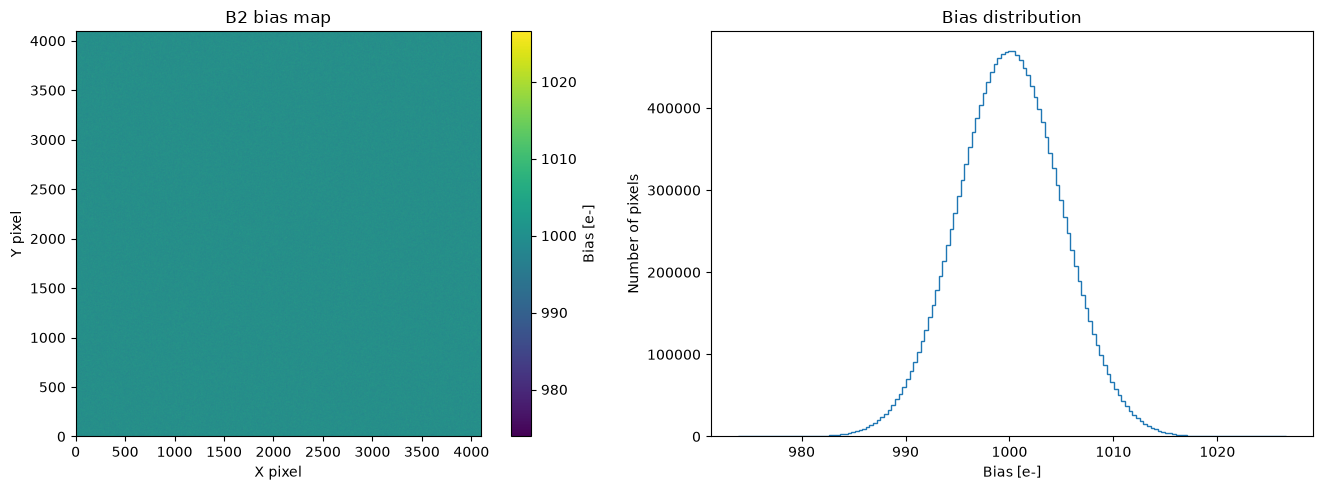

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(
    bias_image,
    origin="lower",
)
plt.colorbar(im, ax=axes[0], label="Bias [e-]")

axes[0].set_title("B2 bias map")
axes[0].set_xlabel("X pixel")
axes[0].set_ylabel("Y pixel")

axes[1].hist(
    bias_image.ravel(),
    bins=150,
    histtype="step",
)

axes[1].set_xlabel("Bias [e-]")
axes[1].set_ylabel("Number of pixels")
axes[1].set_title("Bias distribution")

plt.tight_layout()
plt.show()

### Applying ALL noise maps to a star field

In [14]:
from scopesim.source.source_templates import star_field

stars = star_field(
    n=100000,
    mmax=5,
    mmin=10,
    width=50000,
)

hdulist = simulation(stars)

astar.scopesim.optics.fov_manager - WARNING: For use with the UVEX Slit Mask effect, it's recommended that oversampling_x is even.


 FOVs:   0%|          | 0/294 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

 UVIM Imager PSF Convolution:   0%|          | 0/4096 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

...

 UVIM Imager PSF Convolution:   0%|          | 0/1664 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - WARNING: Flux is not conserved by UVIM imager PSF convolution: difference is 0.02%


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

 UVIM Imager PSF Convolution:   0%|          | 0/416 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - WARNING: Flux is not conserved by UVIM imager PSF convolution: difference is 3.20%
FitsIllumination image-plane shape: (12798, 13098)
FitsIllumination input-map shape: (4096, 4096)
Interpolating illumination map:
FitsIllumination interpolated shape: (12798, 13098)
astar.scopesim.detector.detector_manager - Extracting from 9 detectors...
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 4 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 4 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 5 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 3 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect

#### Visualizing observed star field in one detector

In [15]:
#specify which detector here:
img = hdulist[5].data

print(img.shape)
print("Mean:", np.mean(img))
print("Median:", np.median(img))
print("Std:", np.std(img))

(4096, 4096)
Mean: 869.6230257749557
Median: 835.0
Std: 629.8356461140655


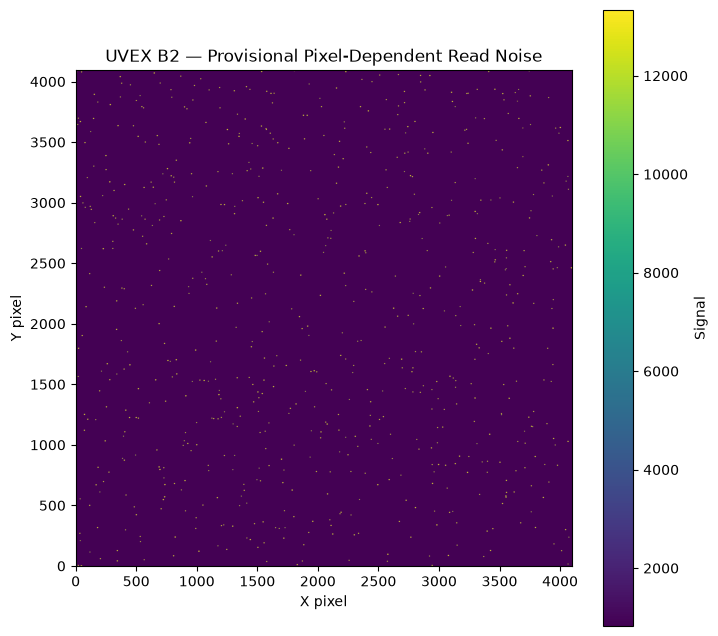

In [16]:
plt.figure(figsize=(8, 8))

vmin = np.percentile(img, 1)
vmax = np.percentile(img, 99.9)

plt.imshow(
    img,
    origin="lower",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Signal")
plt.title("UVEX B2 — Provisional Pixel-Dependent Read Noise")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.show()

#### Visualizing star field in all nine detectors

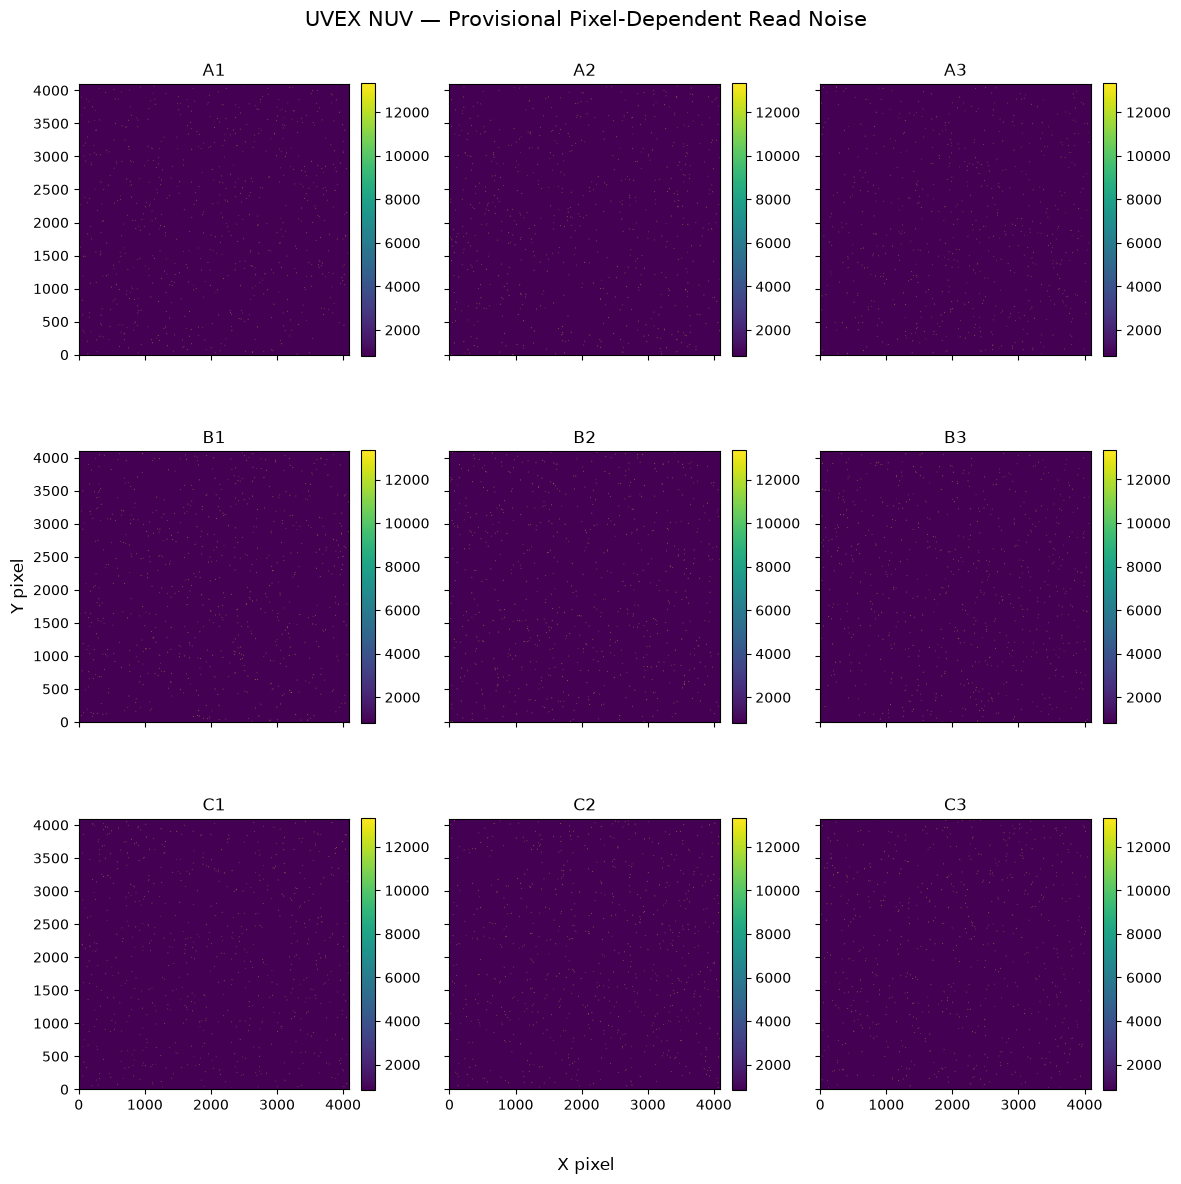

In [17]:
# Physical detector layout and corresponding HDU indices
detector_grid = [
    [("A1", 1), ("A2", 2), ("A3", 3)],
    [("B1", 4), ("B2", 5), ("B3", 6)],
    [("C1", 7), ("C2", 8), ("C3", 9)],
]

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 12),
    sharex=True,
    sharey=True
)

for row, detector_row in enumerate(detector_grid):
    for col, (detector_name, hdu_index) in enumerate(detector_row):

        # Get this detector's simulated image
        img = hdulist[hdu_index].data

        # Set display limits independently for each detector
        vmin = np.percentile(img, 1)
        vmax = np.percentile(img, 99.9)

        ax = axes[row, col]

        im = ax.imshow(
            img,
            origin="lower",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(detector_name)

        # Add a colorbar for each detector
        fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

fig.supxlabel("X pixel")
fig.supylabel("Y pixel")
fig.suptitle(
    "UVEX NUV — Provisional Pixel-Dependent Read Noise",
    fontsize=15
)

plt.tight_layout()
plt.show()